# 384-Well Plate: Compact-Vector Analysis (Primary Analysis)

This notebooks' purpose is to see if the 14-sensor peptide array can distinguish the 12 wines from each other, using only the UV-Vis absorbance readings. And if so, checking if that is discrimination real or an artifact of overfitting a small dataset (72 samples: 12 wines x 6 replicates).

This matters because each peptide sensor is expensive, so a 14-sensor array represents a high per-unit cost. Whether the array can be trimmed without losing discriminatory power (Sections 8-9) is a direct answer to a cost-reduction question.

Notebook organization:

1. Baseline correction: Remove each wine's own natural color from every sensor reading, so what's left is the sensor's chemical response to the wine, not the wine's color itself.
2. Full-feature PCA (fails): This first attempt uses every sensor-wavelength combination (3,164 features) and doesn't work which motivates the following analyses.
3. Wavelength scan: Find each sensor's single most wine-discriminating wavelength, systematically, with no assumed band.
4. Narrower Analyses: Top 5 sensors and top 200 features were tried before committing to the fully compact vector
5. Compact feature vector: Created a vector using each sensors most discriminating wavelength.
6. Unsupervised checks (PCA, UMAP) on the compact vector: Look for structure without telling the method which sample is which wine.
7. Supervised test (LDA) with cross-validation: Testing if a model that has learned the wine identity can actually predict a held-out sample's wine correctly.
8. Grape- and country-level LDA: Checking if the signal is specific to individual wines, or if it also reflects broader grape/geographic differences.
9. Sensor reduction: Can any sensors be dropped without hurting accuracy?
10. Nested cross-validation: A robustness check on steps 6 and 8 which makes sure the reported accuracy isn't inflated by feature selection having already "seen" the data it's later tested on.
11. Grape-variety-pair sub-analysis and summary.


In [205]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import umap

## Load data

The tidy, plate-mapped 384-well dataset built in 01a_Import_Data.ipynb. One row per (Wine, Replicate, Sensor, Wavelength) combination.

In [206]:
#Read master dataframe

master_df_384 = pd.read_csv("../../data/processed/master_df_384.csv")

## 1. Baseline correction

The wine itself has color, independent of any sensor chemistry. Rows A and P of the plate contain wine with no peptide sensor present, so they capture the natural color alone. Every sensor well is corrected against its matching wine's own control wells, so what remains (Corrected_Absorbance) reflects the sensor's chemical response to the wine, not the wine's color bleeding into the reading.

In [207]:
#Isolates the "wine control" wells (rows A and P), which have wine present but no peptide sensor, so they capture the wine's own natural color/absorbance

control = master_df_384[master_df_384["Sensor"] == "Wine control"]

control_baseline = control.groupby(["Wine", "Wavelength"])["Absorbance"].mean().reset_index()
control_baseline = control_baseline.rename(columns = {"Absorbance": "Control_Absorbance"})

In [208]:
sensor_only = master_df_384[master_df_384["Sensor"] != "Wine control"]

corrected_all = sensor_only.merge(control_baseline, on = ["Wine", "Wavelength"], how = "left")
corrected_all["Corrected_Absorbance"] = corrected_all["Absorbance"] - corrected_all["Control_Absorbance"]

In [209]:
corrected_all["Feature"] = corrected_all["Sensor"] + "_" + corrected_all["Wavelength"].astype(str)

pca_matrix = corrected_all.pivot_table(
    index = ["Wine", "Replicate"],
    columns = "Feature",
    values = "Corrected_Absorbance"
)

print(pca_matrix.shape)
print(pca_matrix.isnull().sum().sum())

(72, 3164)
0


## 2. Full-feature PCA

Every sensor-wavelength combination at PCA (14 sensors x 226 wavelengths = 3,164 features).

3,164 features against 72 samples means there are far more ways to fit noise than there is data to constrain the model. This is an informative negative result and is the reason the rest of this notebook uses a much smaller feature set.

In [210]:
X_scaled = StandardScaler().fit_transform(pca_matrix)

pca = PCA()
scores = pca.fit_transform(X_scaled)

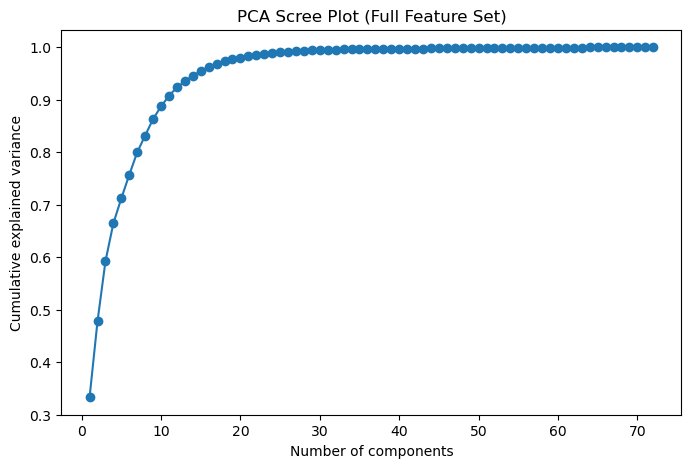

In [211]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = "o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Scree Plot (Full Feature Set)")
plt.show()

In [212]:
print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}, PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.1%}")

PC1: 33.3%, PC1+PC2: 47.8%


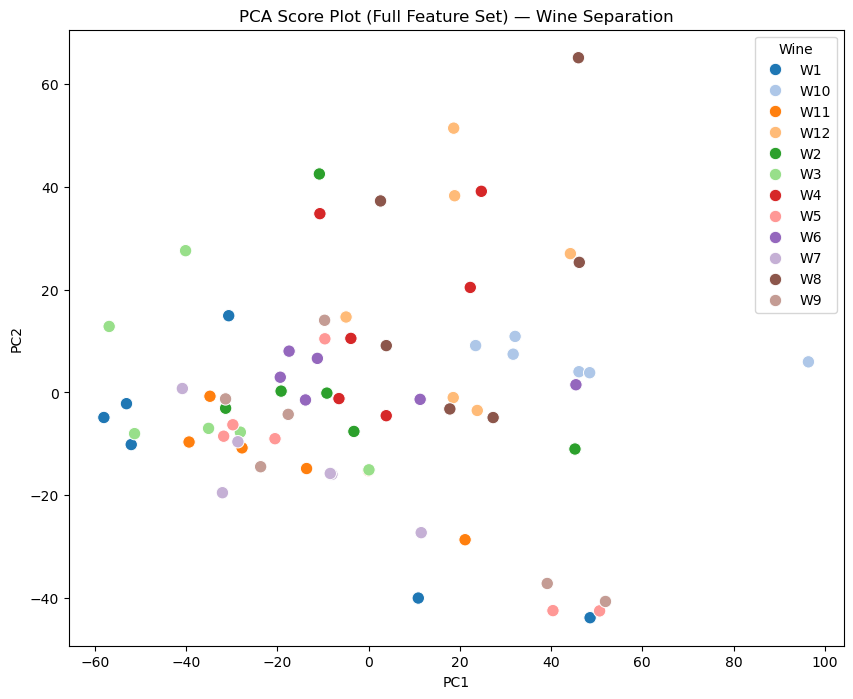

In [213]:
scores_df = pd.DataFrame(scores[:, :2], columns = ["PC1", "PC2"])
scores_df["Wine"] = pca_matrix.index.get_level_values("Wine")

plt.figure(figsize = (10, 8))
sns.scatterplot(data = scores_df, x = "PC1", y = "PC2", hue = "Wine", palette = "tab20", s = 80)
plt.title("PCA Score Plot (Full Feature Set) — Wine Separation")
plt.show()

In [214]:
loadings_pc1 = pd.Series(pca.components_[0], index = pca_matrix.columns)
loading_df = loadings_pc1.reset_index()
loading_df.columns = ["Feature", "Loading"]
loading_df["Sensor"] = loading_df["Feature"].str.rsplit("_", n = 1).str[0]

sensor_contribution = loading_df.groupby("Sensor")["Loading"].apply(lambda x: (x**2).sum())
print(sensor_contribution.sort_values(ascending = False))

Sensor
Cu-WHCCHDHCD-PCV    0.127442
Cu-WAHEDEFF-PCV     0.123697
Cu-PHGGGWGQ-PCV     0.122329
Cu-FHFPHHF-PCV      0.118429
Cu-FHFPHHF-CAS      0.084480
Cu-WEHHHE-PCV       0.068732
Cu-WEEHEE-PCV       0.068665
Cu-WGHGGHHG-PCV     0.068335
Cu-WDDHDD-PCV       0.051176
Cu-WDHHHD-PCV       0.044230
Ni-FHFPHHF-BPR      0.039409
Cu-WEEHEE-CAS       0.039359
Cu-IHIGHHI-PCV      0.039230
Ni-WEEHEE-BPR       0.004487
Name: Loading, dtype: float64


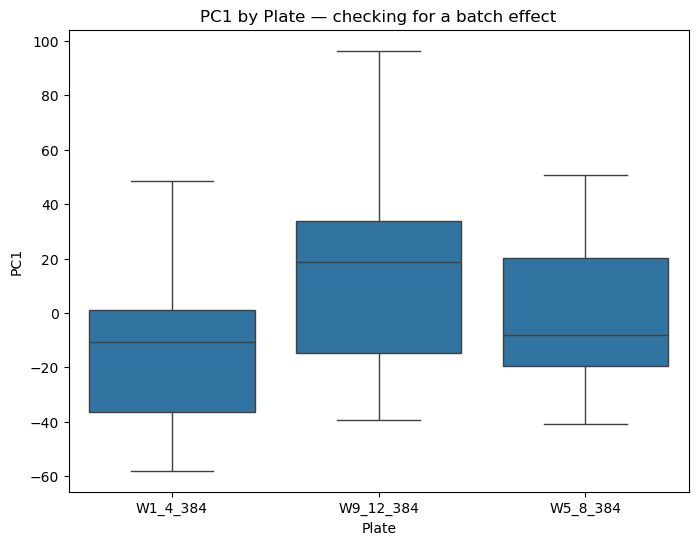

In [215]:
scores_df["Plate"] = corrected_all.drop_duplicates(["Wine", "Replicate"]).set_index(["Wine", "Replicate"]).loc[pca_matrix.index, "Plate"].values

plt.figure(figsize = (8, 6))
sns.boxplot(data = scores_df, x = "Plate", y = "PC1")
plt.title("PC1 by Plate — checking for a batch effect")
plt.show()

Conclusion — full-feature PCA: PC1 is dominated by sensors with weak wine-discrimination power, not the strongest discriminators, with a partial plate effect also present. This does not recover the wine-discriminating signal identified by the wavelength scan below, and motivates restricting each sensor to its single most informative wavelength rather than using the full spectrum.

## 3. Wavelength scan

For every sensor, every one of its 226 wavelengths are individually tested, using a one-way ANOVA F-statistic to ask how well a single wavelength can separate the 12 wines. No wavelength band is assumed in advance, so this is a systematic scan rather than a guess.

This identifies, per sensor, which single wavelength actually carries the wine-discriminating signal, which is what makes the compact vector below.

In [216]:
wavelength_scores = []

for sensor in master_df_384[master_df_384["Sensor"] != "Wine control"]["Sensor"].unique():
    sensor_data = master_df_384[master_df_384["Sensor"] == sensor]

    for wavelength in sensor_data["Wavelength"].unique():
        wl_data = sensor_data[sensor_data["Wavelength"] == wavelength]
        groups = [g["Absorbance"].values for _, g in wl_data.groupby("Wine")]
        f_stat, p_val = stats.f_oneway(*groups)
        wavelength_scores.append({
            "Sensor": sensor,
            "Wavelength": wavelength,
            "F_statistic": f_stat,
            "p_value": p_val
        })

wavelength_scores = pd.DataFrame(wavelength_scores)

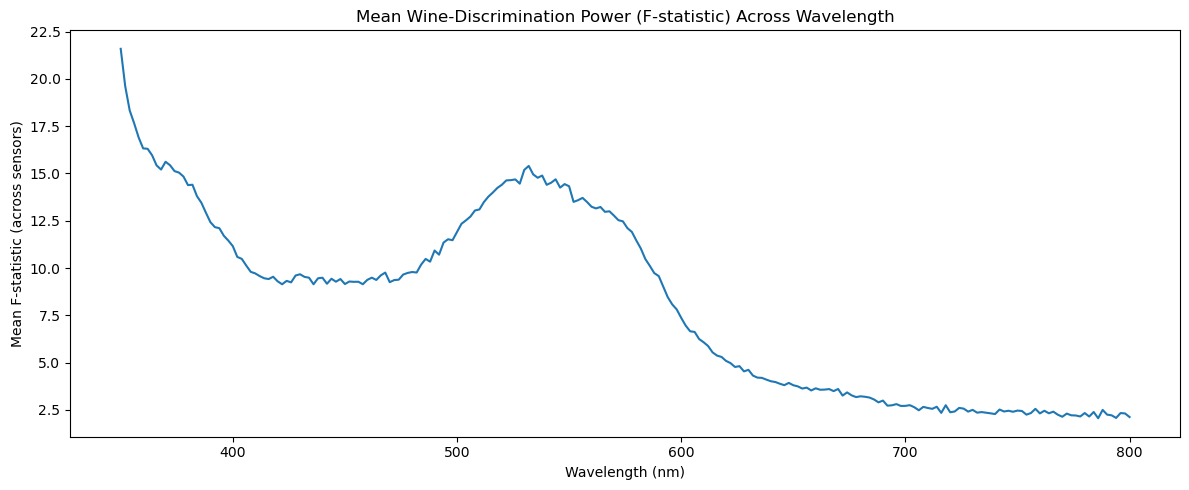

In [217]:
mean_by_wavelength = wavelength_scores.groupby("Wavelength")["F_statistic"].mean()

plt.figure(figsize = (12, 5))
plt.plot(mean_by_wavelength.index, mean_by_wavelength.values)
plt.title("Mean Wine-Discrimination Power (F-statistic) Across Wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean F-statistic (across sensors)")
plt.tight_layout()
plt.show()

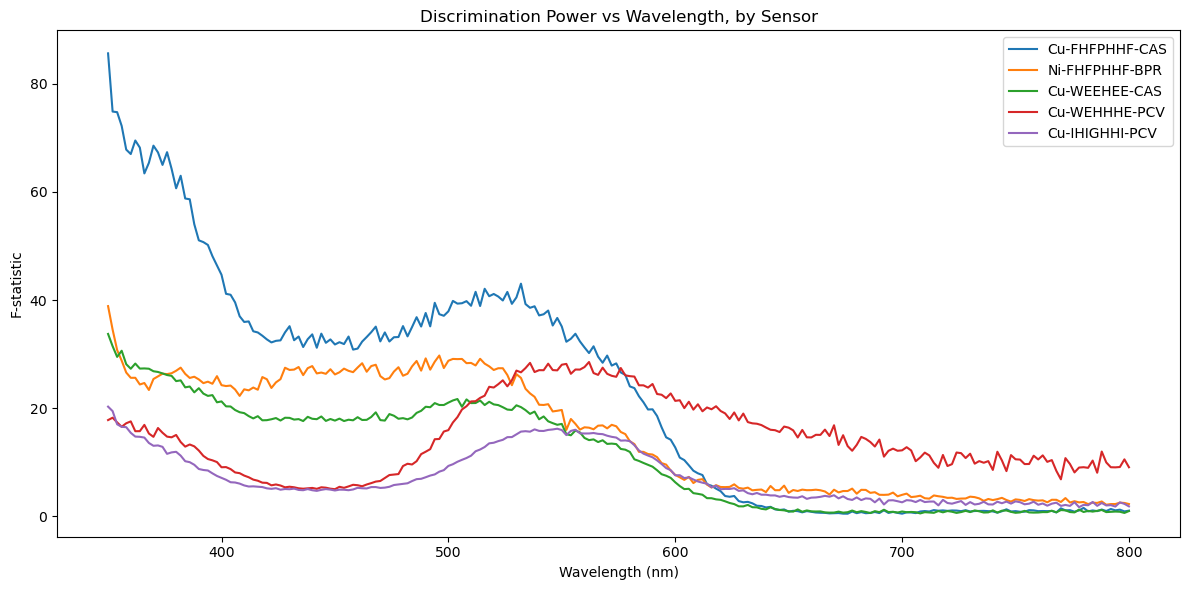

In [218]:
top_sensors = wavelength_scores.groupby("Sensor")["F_statistic"].max().sort_values(ascending = False).head(5).index

plt.figure(figsize = (12, 6))
for sensor in top_sensors:
    subset = wavelength_scores[wavelength_scores["Sensor"] == sensor]
    plt.plot(subset["Wavelength"], subset["F_statistic"], label = sensor)

plt.legend()
plt.title("Discrimination Power vs Wavelength, by Sensor")
plt.xlabel("Wavelength (nm)")
plt.ylabel("F-statistic")
plt.tight_layout()
plt.show()

In [219]:
#For each sensor, identify its single best (most discriminating) wavelength

best_wavelength_per_sensor = wavelength_scores.loc[
    wavelength_scores.groupby("Sensor")["F_statistic"].idxmax()
][["Sensor", "Wavelength", "F_statistic", "p_value"]].sort_values("F_statistic", ascending = False)

print(best_wavelength_per_sensor)

                Sensor  Wavelength  F_statistic       p_value
1582    Cu-FHFPHHF-CAS         350    85.619537  2.006183e-32
2486    Ni-FHFPHHF-BPR         350    38.875035  3.567528e-23
2034     Cu-WEEHEE-CAS         350    33.729645  1.333125e-21
2366     Cu-WEHHHE-PCV         562    28.537334  8.510176e-20
0       Cu-IHIGHHI-PCV         350    20.284751  2.720727e-16
1227  Cu-WHCCHDHCD-PCV         544    20.239461  2.862480e-16
678    Cu-PHGGGWGQ-PCV         350    17.071090  1.256273e-14
2806     Cu-WDDHDD-PCV         538    16.819642  1.732151e-14
904     Cu-FHFPHHF-PCV         350    13.328370  2.206715e-12
226      Cu-WEEHEE-PCV         350    12.879437  4.366927e-12
2938     Ni-WEEHEE-BPR         350    12.731640  5.485462e-12
452    Cu-WAHEDEFF-PCV         350     6.452386  6.087768e-07
1496   Cu-WGHGGHHG-PCV         630     6.174329  1.134919e-06
1908     Cu-WDHHHD-PCV         550     5.736772  3.093776e-06


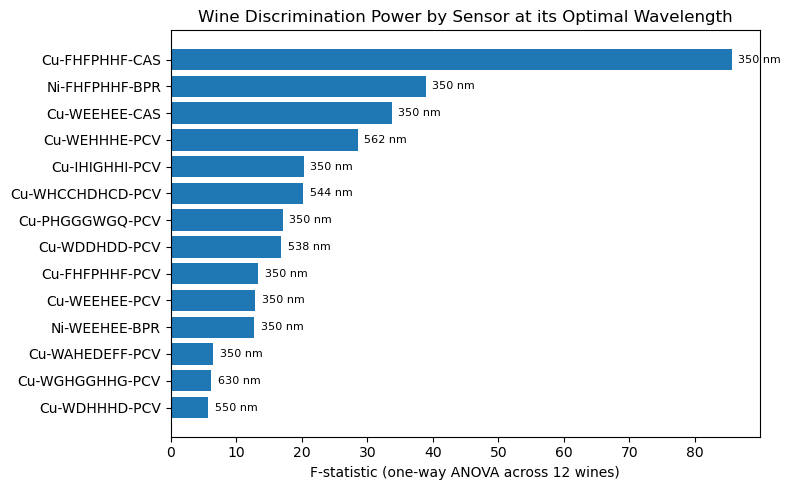

In [220]:
d = best_wavelength_per_sensor.sort_values("F_statistic")

plt.figure(figsize = (8, 5))
plt.barh(d["Sensor"], d["F_statistic"])
for y, (f, w) in enumerate(zip(d["F_statistic"], d["Wavelength"])):
    plt.text(f + 1, y, f"{w} nm", va = "center", fontsize = 8)

plt.title("Wine Discrimination Power by Sensor at its Optimal Wavelength")
plt.xlabel("F-statistic (one-way ANOVA across 12 wines)")
plt.tight_layout()
plt.show()

At their individually optimal wavelengths, all 14 sensors show statistically significant wine discrimination ( all p<0.001). The strongest single discriminator is Cu-FHFPHHF-CAS at 350 nm (F = 85.6), more than twice the F-statistic of the second-strongest sensor Ni-FHFPHHF-BPR at 350nm (F = 38.9). The weakest sensor is Cu-WDHHHD-PCV at 550 nm (F = 5.7, p<10⁻⁶).

### 4. Two narrower analyses tried before committing to the full compact vector

Before restricting every sensor to a single wavelength (the compact vector built in Section 5 below), two less aggressive cuts were tried first. This was to check whether a narrower selection already solved the separation problem on its own. These cuts included:

1. Top 5 sensors (by F-statistic), keeping each sensor's full 226-wavelength spectrum.
2. Top 200 individual (sensor, wavelength) combinations, ranked directly by F-statistic.

Both selections are built from the wavelength_scores table computed in the wavelength scan above, rather than reading a separate file.

In [221]:
#PCA restricted to the 5 sensors with the strongest F-statistic

top5_sensor_list = best_wavelength_per_sensor.sort_values("F_statistic", ascending = False).head(5)["Sensor"].tolist()
print(top5_sensor_list)

top5_columns = [col for col in pca_matrix.columns if col.rsplit("_", 1)[0] in top5_sensor_list]
pca_matrix_top5 = pca_matrix[top5_columns]

print(pca_matrix_top5.shape)   #expect (72, ~1130) - 5 sensors x 226 wavelengths

X_scaled_top5 = StandardScaler().fit_transform(pca_matrix_top5)
pca_top5 = PCA()
scores_top5 = pca_top5.fit_transform(X_scaled_top5)

print(pca_top5.explained_variance_ratio_[:2].sum())


['Cu-FHFPHHF-CAS', 'Ni-FHFPHHF-BPR', 'Cu-WEEHEE-CAS', 'Cu-WEHHHE-PCV', 'Cu-IHIGHHI-PCV']
(72, 1130)
0.6051734276475078


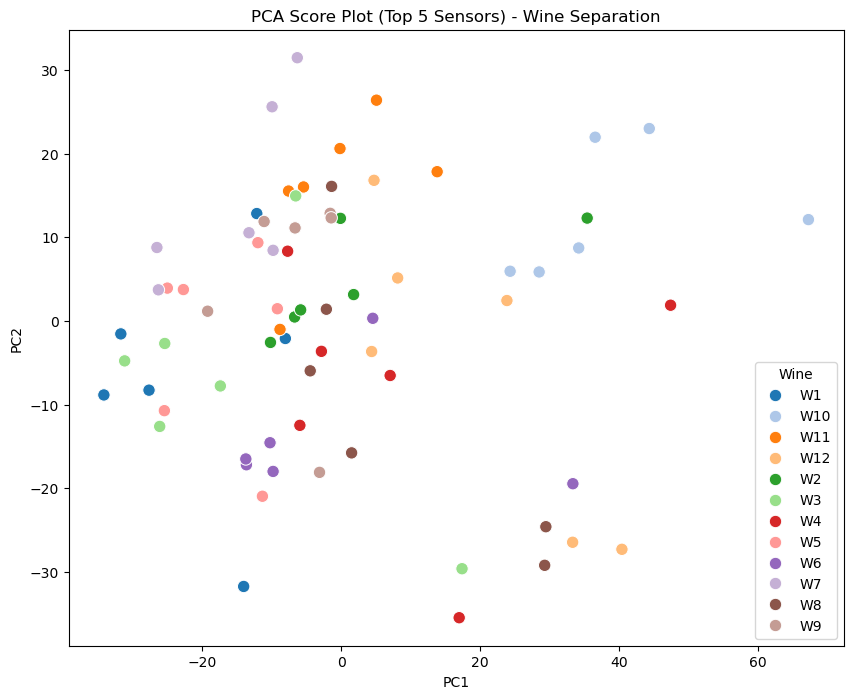

In [222]:
#Score plot - top 5 sensors

scores_top5_df = pd.DataFrame(scores_top5[:, :2], columns = ["PC1", "PC2"])
scores_top5_df["Wine"] = pca_matrix.index.get_level_values("Wine")

plt.figure(figsize = (10,8))
sns.scatterplot(data = scores_top5_df, x = "PC1", y = "PC2", hue = "Wine", palette = "tab20", s = 80)
plt.title("PCA Score Plot (Top 5 Sensors) - Wine Separation")
plt.show()


In [223]:
#Loadings for the top-5-sensor PCA

loadings_top5 = pd.Series(pca_top5.components_[0], index = pca_matrix_top5.columns)
loading_df_top5 = loadings_top5.reset_index()
loading_df_top5.columns = ["Feature", "Loading"]
loading_df_top5["Sensor"] = loading_df_top5["Feature"].str.rsplit("_", n = 1).str[0]

print(loading_df_top5.groupby("Sensor")["Loading"].apply(lambda x: (x**2).sum()).sort_values(ascending = False))


Sensor
Cu-WEEHEE-CAS     0.285404
Cu-WEHHHE-PCV     0.268357
Ni-FHFPHHF-BPR    0.189834
Cu-FHFPHHF-CAS    0.160806
Cu-IHIGHHI-PCV    0.095598
Name: Loading, dtype: float64


W1 and W10 separate clearly along PC1 in this version and W3 partially separates. Most other wines still overlap. PC1+PC2 explain 60.5% of variance, up from 47.8% in the full-feature version. This is an improvement, but still short of full 12-way separation.

In [224]:
#PCA restricted to the top 200 individual (sensor, wavelength)
#combinations by F-statistic - finer-grained than the top-5-sensor version

top_features = wavelength_scores.sort_values("F_statistic", ascending = False).head(200)
top_features["Feature"] = top_features["Sensor"] + "_" + top_features["Wavelength"].astype(str)

top200_columns = [col for col in pca_matrix.columns if col in top_features["Feature"].values]
pca_matrix_top200 = pca_matrix[top200_columns]
print(pca_matrix_top200.shape)   #expect (72, 200)

X_scaled_top200 = StandardScaler().fit_transform(pca_matrix_top200)
pca_top200 = PCA()
scores_top200 = pca_top200.fit_transform(X_scaled_top200)

print(pca_top200.explained_variance_ratio_[:2].sum())


(72, 200)
0.8528947029217133


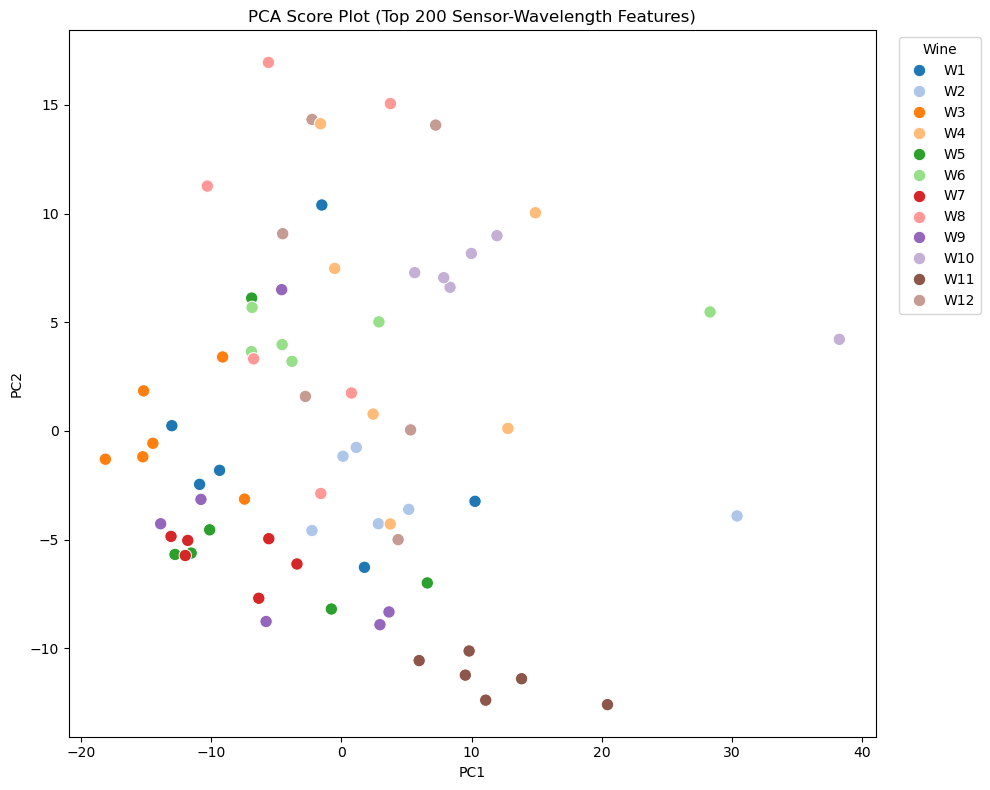

In [225]:
#Score plot - top 200 features

scores_top200_df = pd.DataFrame(scores_top200[:, :2], columns = ["PC1", "PC2"])
scores_top200_df["Wine"] = pca_matrix.index.get_level_values("Wine")

#Order the legend numerically rather than alphabetically
wine_order = sorted(scores_top200_df["Wine"].unique(), key = lambda w: int(w[1:]))

plt.figure(figsize = (10, 8))
sns.scatterplot(data = scores_top200_df, x = "PC1", y = "PC2", hue = "Wine", 
                hue_order = wine_order, palette = "tab20", s = 80)
plt.title("PCA Score Plot (Top 200 Sensor-Wavelength Features)")
plt.legend(title = "Wine", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.tight_layout()
plt.show()


In [226]:
#Loadings for the top-200-feature PCA

loadings_top200 = pd.Series(pca_top200.components_[0], index = pca_matrix_top200.columns)
loading_df_top200 = loadings_top200.reset_index()
loading_df_top200.columns = ["Feature", "Loading"]
loading_df_top200["Sensor"] = loading_df_top200["Feature"].str.rsplit("_", n = 1).str[0]

print(loading_df_top200.groupby("Sensor")["Loading"].apply(lambda x: (x**2).sum()).sort_values(ascending = False))


Sensor
Cu-FHFPHHF-CAS    0.913795
Cu-WEHHHE-PCV     0.044706
Cu-WEEHEE-CAS     0.021631
Ni-FHFPHHF-BPR    0.019868
Name: Loading, dtype: float64


Cu-FHFPHHF-CAS alone accounts for the large majority of PC1 in this version, consistent with the wavelength-scan finding that this sensor carries the strongest single discriminatory signal. PC1+PC2 now explain ~85% of variance, a tighter overall grouping than either previous version, though still not full 12-way separation.

Neither narrower cut (top 5 sensors, top 200 features) achieves complete wine-by-wine separation on its own. This motivates the fully compact vector built next which includes one wavelength per sensor, across all 14 sensors.

## 5. Compact feature vector

Rather than using all 226 wavelengths per sensor, each sensor is reduced to its own best-discriminating wavelength from the scan above. This produces a 72 x 14 matrix (one row per Wine + Replicate, one column per sensor), instead of the 72 x 3,164 used in the full-feature attempt or either of the narrower cuts tried above.

In [227]:
#Build the compact feature matrix using each sensor's best wavelength only

compact_features = []
for _, row in best_wavelength_per_sensor.iterrows():
    sensor, wl = row["Sensor"], row["Wavelength"]
    subset = corrected_all[(corrected_all["Sensor"] == sensor) & (corrected_all["Wavelength"] == wl)]
    subset = subset[["Wine", "Replicate", "Corrected_Absorbance"]].rename(columns = {"Corrected_Absorbance": sensor})
    compact_features.append(subset.set_index(["Wine", "Replicate"]))

compact_matrix = pd.concat(compact_features, axis = 1)
print(compact_matrix.shape)   
print(compact_matrix.isnull().sum().sum())

(72, 14)
0


In [228]:
#Saved as a clean artifact for 04_Clustering.ipynb

compact_matrix.reset_index().to_csv("../../data/processed/compact_matrix_384.csv", index = False)

A  visual check on two wines the scan flags as well-separated by the top sensor (`Cu-FHFPHHF-CAS` at 350nm). This is to confirm the statistic corresponds to a real, visible difference rather than an artifact of the test.

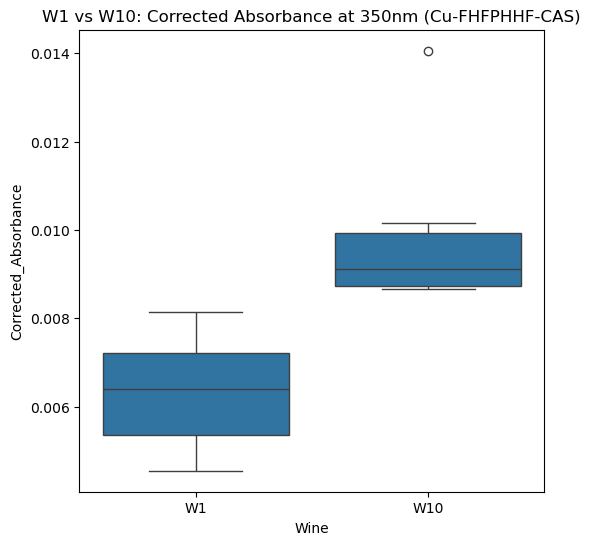

In [229]:
check_350 = corrected_all[
    (corrected_all["Sensor"] == "Cu-FHFPHHF-CAS") &
    (corrected_all["Wavelength"] == 350) &
    (corrected_all["Wine"].isin(["W1", "W10"]))
]

plt.figure(figsize = (6, 6))
sns.boxplot(data = check_350, x = "Wine", y = "Corrected_Absorbance")
plt.title("W1 vs W10: Corrected Absorbance at 350nm (Cu-FHFPHHF-CAS)")
plt.show()

## 6. Unsupervised Analyses: PCA and UMAP on the compact vector

PCA and UMAP don't know which sample belongs to which wine, they just look for the largest sources of variation in the data. Checking these before the supervised LDA step below establishes whether there's any visible structure at all, without providing the labels.

In [230]:
X_scaled_compact = StandardScaler().fit_transform(compact_matrix)

pca_compact = PCA()
scores_compact = pca_compact.fit_transform(X_scaled_compact)

print(pca_compact.explained_variance_ratio_[:2].sum())

0.5985554468539893


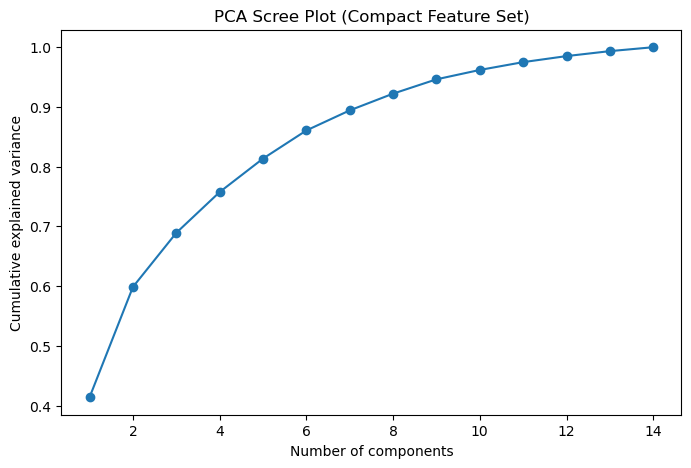

In [231]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, len(pca_compact.explained_variance_ratio_) + 1), pca_compact.explained_variance_ratio_.cumsum(), marker = "o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Scree Plot (Compact Feature Set)")
plt.show()

In [232]:
print(f"PC1: {pca_compact.explained_variance_ratio_[0]:.1%}, PC1+PC2: {pca_compact.explained_variance_ratio_[:2].sum():.1%}")

PC1: 41.4%, PC1+PC2: 59.9%


PC1 alone explains 41.4% of variance, and PC1+PC2 together explain 59.9%. This is an improvement over the full-feature version (47.8%), reflecting the reduced dimensionality of the compact vector, though lower than the 85% achieved by the earlier wavelength-only feature-selection approach, which was more targeted at a single sensor's signal rather than a representation across all 14 sensors.

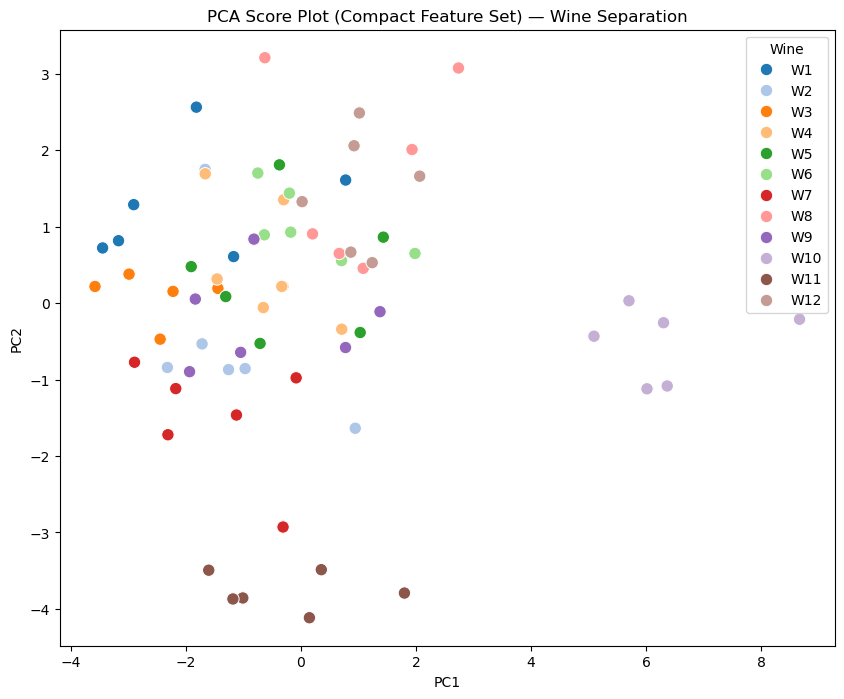

In [233]:
scores_compact_df = pd.DataFrame(scores_compact[:, :2], columns = ["PC1", "PC2"])
scores_compact_df["Wine"] = compact_matrix.index.get_level_values("Wine")

plt.figure(figsize = (10, 8))
sns.scatterplot(data = scores_compact_df, x = "PC1", y = "PC2", hue = "Wine", palette = "tab20", s = 80)
plt.title("PCA Score Plot (Compact Feature Set) — Wine Separation")
plt.show()

W10 separates clearly along PC1, and W11 sits distinctly along PC2, but most other wines continue to overlap substantially near the center of the plot. This partial separation is consistent with previous PCA attempts. Since PCA, as an unsupervised method, it will capture the largest overall sources of variance in the data rather than specifically wine-discriminating variance.

In [234]:
loadings_compact = pd.Series(pca_compact.components_[0], index = compact_matrix.columns)
print(loadings_compact.reindex(loadings_compact.abs().sort_values(ascending = False).index))

Cu-WHCCHDHCD-PCV    0.360121
Cu-WAHEDEFF-PCV     0.351980
Cu-WEEHEE-CAS       0.338339
Cu-WEEHEE-PCV       0.322485
Cu-WEHHHE-PCV       0.294451
Cu-FHFPHHF-PCV      0.290391
Cu-PHGGGWGQ-PCV     0.284800
Cu-WGHGGHHG-PCV     0.269729
Cu-WDDHDD-PCV       0.238325
Ni-FHFPHHF-BPR      0.226938
Cu-WDHHHD-PCV       0.201984
Cu-FHFPHHF-CAS      0.186583
Cu-IHIGHHI-PCV      0.138131
Ni-WEEHEE-BPR      -0.008301
dtype: float64


Unlike the earlier wavelength-targeted PCA (where a single sensor, Cu-FHFPHHF-CAS, accounted for over 91.4% of PC1), PC1 here reflects a balanced contribution across most sensors (0.19-0.36 each), with Ni-WEEHEE-BPR contributing almost nothing (-0.008). This is expected since the compact vector reduces each sensor to a single value, PC1 captures general covariance in overall response magnitude across sensors, rather than the specific wine-discriminating signal isolated by the earlier wavelength-level analysis. The two PCA versions are therefore answering related but distinct questions, not producing conflicting results.

Because PCA here is run on the same compact vector that the F-statistic scan already selected, this is also checking for consistency on that selection.

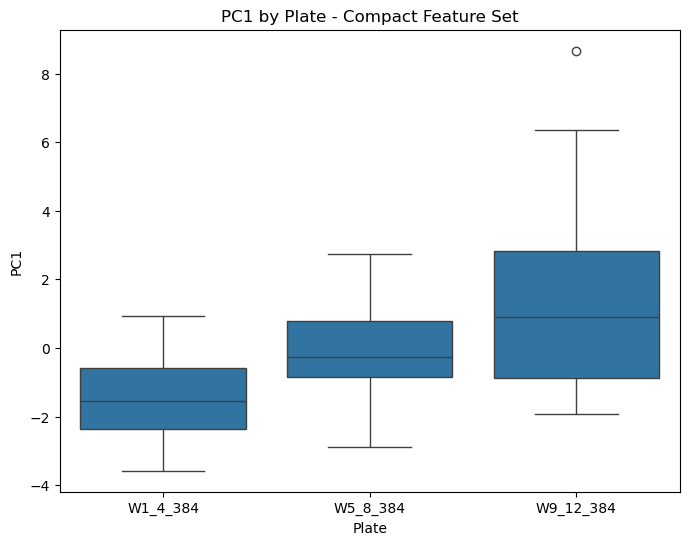

In [235]:
scores_compact_df["Plate"] = corrected_all.drop_duplicates(["Wine", "Replicate"]).set_index(["Wine", "Replicate"]).loc[compact_matrix.index, "Plate"].values

plt.figure(figsize = (8, 6))
sns.boxplot(data = scores_compact_df, x = "Plate", y = "PC1")
plt.title("PC1 by Plate - Compact Feature Set")
plt.show()

### UMAP — Nonlinear alternative

PCA and LDA are both linear methods. UMAP is included as a nonlinear check, in case wine-related structure exists in a form linear methods can't capture.

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


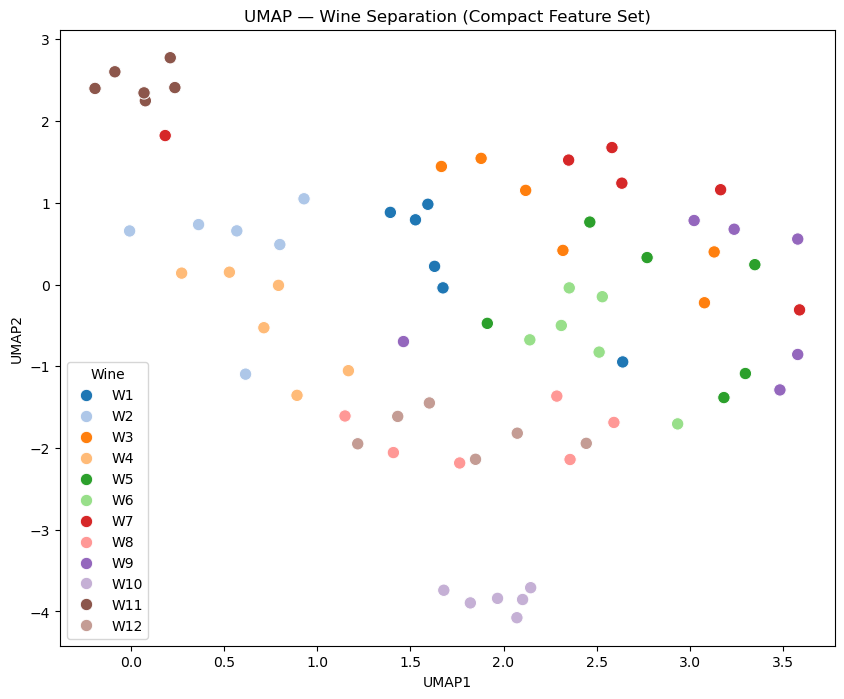

In [236]:
reducer = umap.UMAP(n_components = 2, random_state = 42)
umap_scores = reducer.fit_transform(X_scaled_compact)

umap_df = pd.DataFrame(umap_scores, columns = ["UMAP1", "UMAP2"])
umap_df["Wine"] = compact_matrix.index.get_level_values("Wine")

plt.figure(figsize = (10, 8))
sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Wine", palette = "tab20", s = 80)
plt.title("UMAP — Wine Separation (Compact Feature Set)")
plt.show()

UMAP shows moderate grouping, (W11, W2, and W7 each cluster loosely) but separation is visibly weaker than the supervised LDA result and comparable to standard PCA. As an
unsupervised, nonlinear method, UMAP was included to check for structure that a linear method might miss. The absence of a stronger result here suggests wine-related structure in this dataset is reasonably well captured by linear methods, rather than requiring a nonlinear representation.

## 7. LDA on the compact vector

LDA is supervised, so it's given wine identity while fitting, and  finds the projection that best separates the known groups. This means it will typically look like it separates wines well even if that separation doesn't generalize, the score plot alone is not evidence of a real effect. The cross-validation step below will test that.

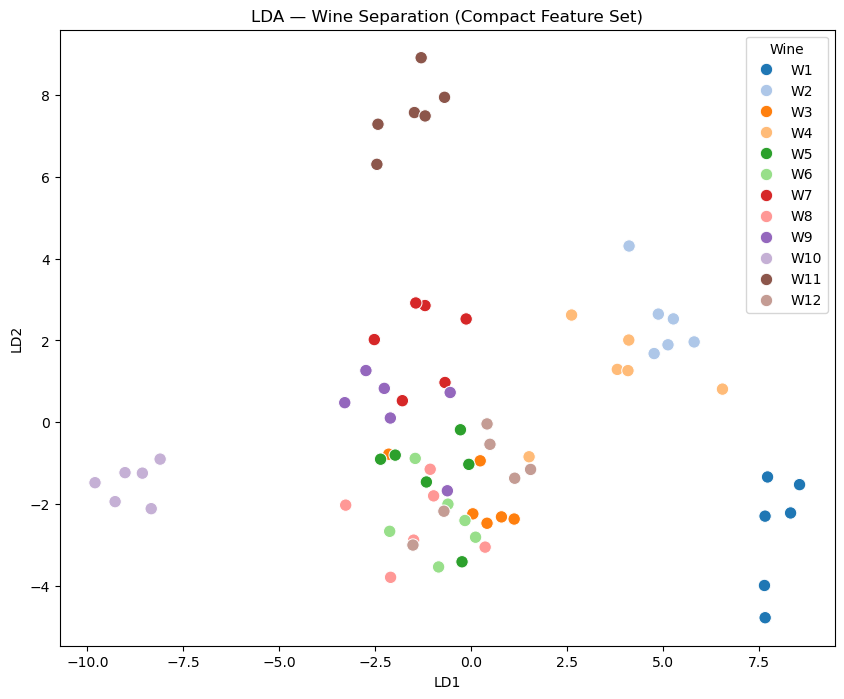

In [237]:
y = compact_matrix.index.get_level_values("Wine")

lda = LinearDiscriminantAnalysis(n_components = 2)
lda_scores = lda.fit_transform(X_scaled_compact, y)

lda_df = pd.DataFrame(lda_scores, columns = ["LD1", "LD2"])
lda_df["Wine"] = y.values

plt.figure(figsize = (10, 8))
sns.scatterplot(data = lda_df, x = "LD1", y = "LD2", hue = "Wine", palette = "tab20", s = 80)
plt.title("LDA — Wine Separation (Compact Feature Set)")
plt.show()

The resulting separation is visibly tighter than either PCA or UMAP: W1, W7, W10, and W11 each form distinct, well-separated clusters, with a looser grouping visible for W3/W4 and W5/W6. Because LDA is supervised and fitted on only 6 replicates per class relative to 14 features, this plot alone is not enough evidence of real separation. Overfitting is a risk at this sample size, which is addressed by the cross-validation check below.

### Leave-one-out cross-validation

With only 72 samples across 12 classes, a single train/test split would test each class on essentially one sample, which is too noisy. LOOCV instead holds out each of the 72 samples in turn, trains on the other 71, and predicts the one held-out sample. So, every sample gets tested exactly once, and the reported accuracy reflects performance on data the model never trained on.

In [238]:
loo = LeaveOneOut()
cv_scores = cross_val_score(LinearDiscriminantAnalysis(), X_scaled_compact, y, cv = loo)
print(f"Leave-one-out accuracy: {cv_scores.mean():.3f}")

Leave-one-out accuracy: 0.722


Leave-one-out cross-validation gives an accuracy of 72.2% across all 12 wine classes, substantially above the 8.3% expected from chance alone. This confirms the separation visible in the LDA score plot generalizes to held-out samples rather than reflecting overfitting to the training data, and is the strongest quantitative evidence of wine discrimination produced in this notebook. The confusion matrix below identifies exactly where the remaining ~28% of misclassifications occur.

A caveat found was that the wavelength selection that built the compact vector was performed once on the full 72-sample dataset, before this cross-validation loop. Meaning each held-out test sample had technically already influenced which wavelength was chosen for each sensor. Section 10 repeats this check with wavelength selection re-run independently inside each fold, to confirm this doesn't inflate the accuracy reported here.

In [239]:
def wine_key(w):
    return int(w[1:])

wine_order = sorted(master_df_384["Wine"].unique(), key = wine_key)

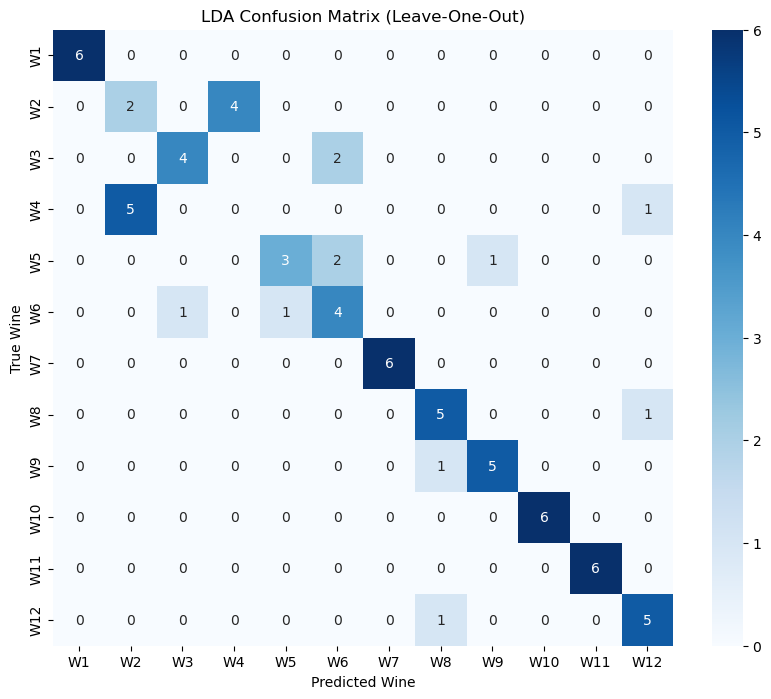

In [240]:
pipe = Pipeline([
("scaler", StandardScaler()),
 ("lda", LinearDiscriminantAnalysis()),
])

#Pass unscaled compact matrix so that the scaler fits inside each CV fold
y_pred = cross_val_predict(pipe, X_scaled_compact, y, cv = loo)

labels_sorted = sorted(y.unique(), key = wine_key)
cm = confusion_matrix(y, y_pred, labels = labels_sorted)

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = "d", 
            xticklabels = labels_sorted, yticklabels = labels_sorted, 
            cmap = "Blues")
plt.xlabel("Predicted Wine")
plt.ylabel("True Wine")
plt.title("LDA Confusion Matrix (Leave-One-Out)")
plt.show()

In [241]:
for wine in labels_sorted:
    correct = cm[labels_sorted.index(wine), labels_sorted.index(wine)]
    total = cm[labels_sorted.index(wine), :].sum()
    print(f"{wine}: {correct}/{total}")

W1: 6/6
W2: 2/6
W3: 4/6
W4: 0/6
W5: 3/6
W6: 4/6
W7: 6/6
W8: 5/6
W9: 5/6
W10: 6/6
W11: 6/6
W12: 5/6


Seven of twelve wines are classified correctly in all or nearly all held-out trials (W1, W7, W10, W11 at 6/6; W8, W9, W12 at 5/6), indicating the compact feature vector resolves most wines cleanly. The dominant source of error is a specific confusion between W2 (Cabernet Sauvignon, California) and W4 (Syrah, Rhone Valley). Two wines that share neither grape variety nor region. Notably, W2 was never confused with W10, its actual same-grape counterpart from the pairwise grape-variety analysis, despite that pair showing an extremely large pairwise F-statistic (F = 648.3) when tested in isolation. This indicates that strong pairwise separability between two wines does not guarantee either wine is well-separated from every other wine in the full 12-class problem. A second, more diffuse pattern is also visible: W6 is misclassified as several different true wines (W3, W5), rather than being confused with one specific counterpart, suggesting its feature-space position may be less distinctive overall rather than specifically similar to any single other wine.

## 8. LDA at grape variety and country levels

Wine-level LDA (above) tests is the array can tell W1 from W2, from W3, etc. This section asks if the signal is specific to individual wines, or does it also carry information about broader groupings like grape variety or country of origin. This is important for describing what the array could be detecting.

In [242]:
grape_map = {
    "W1": "Malbec", "W7": "Malbec",
    "W2": "Cabernet Sauvignon", "W10": "Cabernet Sauvignon",
    "W3": "Tempranillo",
    "W4": "Syrah", "W8": "Syrah",
    "W5": "Pinot Noir", "W12": "Pinot Noir",
    "W6": "Merlot", "W11": "Merlot",
    "W9": "Sangiovese"
}

country_map = {
    "W1": "USA", "W2": "USA", "W5": "USA",
    "W3": "Spain",
    "W4": "France", "W8": "France", "W10": "France", "W12": "France",
    "W6": "Australia",
    "W7": "Argentina",
    "W9": "Italy",
    "W11": "Canada"
}

wine_labels = compact_matrix.index.get_level_values("Wine")
grape_labels = wine_labels.map(grape_map)
country_labels = wine_labels.map(country_map)

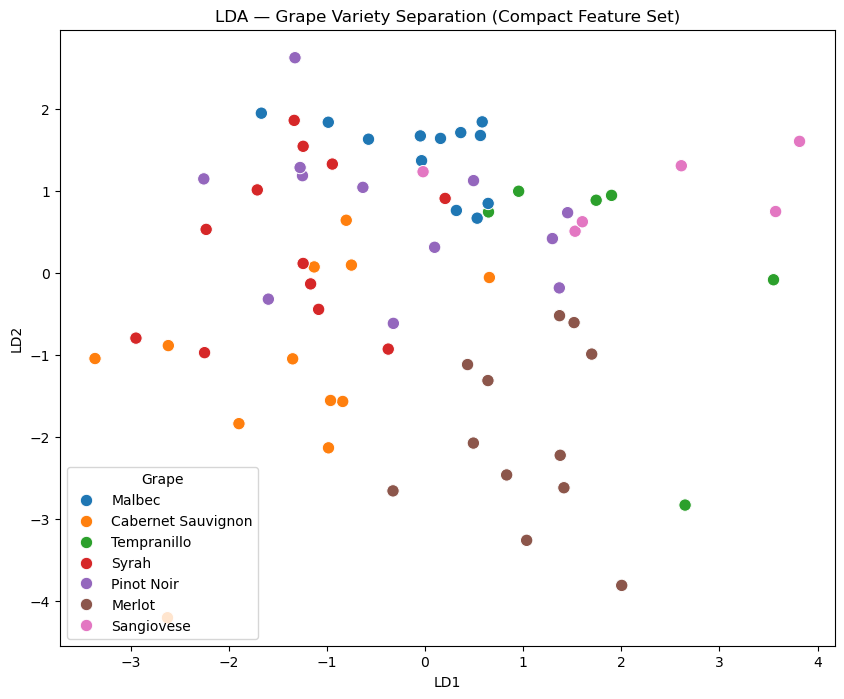

Grape-level leave-one-out accuracy: 0.486


In [243]:
lda_grape = LinearDiscriminantAnalysis(n_components = 2)
lda_grape_scores = lda_grape.fit_transform(X_scaled_compact, grape_labels)

lda_grape_df = pd.DataFrame(lda_grape_scores, columns = ["LD1", "LD2"])
lda_grape_df["Grape"] = grape_labels.values

plt.figure(figsize = (10, 8))
sns.scatterplot(data = lda_grape_df, x = "LD1", y = "LD2", hue = "Grape", palette = "tab10", s = 80)
plt.title("LDA — Grape Variety Separation (Compact Feature Set)")
plt.show()

cv_grape = cross_val_score(LinearDiscriminantAnalysis(), X_scaled_compact, grape_labels, cv = LeaveOneOut())
print(f"Grape-level leave-one-out accuracy: {cv_grape.mean():.3f}")

Grape-level LDA achieves 48.6% leave-one-out accuracy across seven grape varieties (chance level ~14.3%). Which is above chance, but substantially
lower than the 72.2% achieved at the individual wine level. This is expected because wine identity reflects a combination of many aspects including grape variety, vintage, winemaking technique, and terroir. A model trained to distinguish individual wines may therefore recover wine-specific chemical signatures easier than it isolates the narrower signal attributable to grape variety alone.

However, two of the seven grape classes (Tempranillo, Sangiovese) are represented by a single wine each. In LOOCV, the fold that holds out the wine's one replicate leaves zero training examples of that class for the model to learn from. So, those two classes are not meaningfully tested by this procedure, and the 48.6% figure should be read with that in mind. The confusion matrix below examines whether reduced accuracy is distributed evenly across grape varieties or concentrated among specific ones.

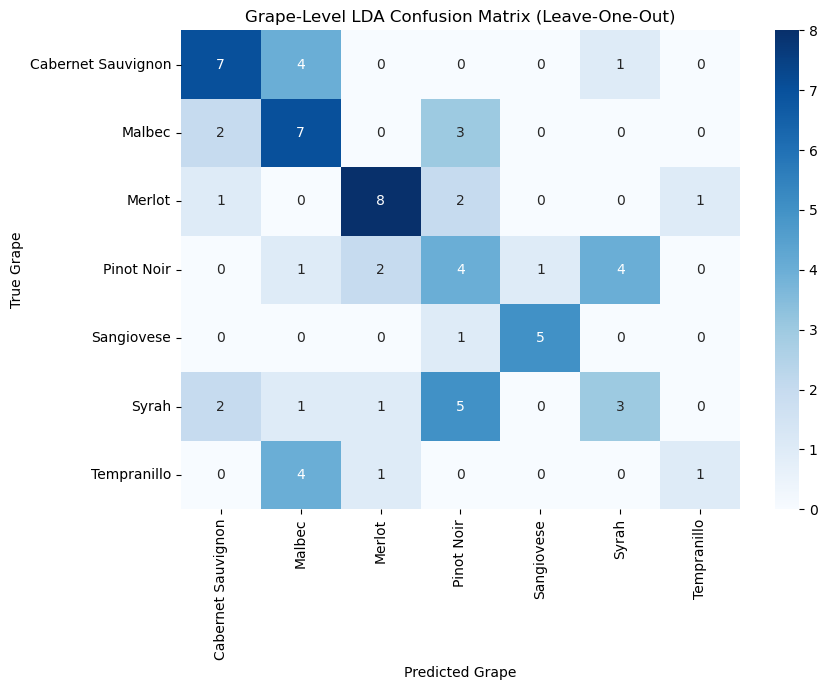

In [244]:
#Confusion matrix for grape-level LDA to check if low accuracy is driven by specific grape varieties, or spread evenly across all seven

grape_pred = cross_val_predict(LinearDiscriminantAnalysis(), X_scaled_compact, grape_labels, cv = loo)

grape_labels_sorted = sorted(pd.Series(grape_labels).unique())
cm_grape = confusion_matrix(grape_labels, grape_pred, labels = grape_labels_sorted)

plt.figure(figsize = (9, 7))
sns.heatmap(cm_grape, annot = True, fmt = "d", xticklabels = grape_labels_sorted, yticklabels = grape_labels_sorted, cmap = "Blues")
plt.xlabel("Predicted Grape")
plt.ylabel("True Grape")
plt.title("Grape-Level LDA Confusion Matrix (Leave-One-Out)")
plt.tight_layout()
plt.show()

The confusion matrix reveals that reduced grape-level accuracy is not distributed evenly, but concentrated in specific pairs. Syrah and Pinot Noir are the most frequently confused pair (5 and 4 misclassifications), consistent with the visual overlap of these two varieties observed in the LDA score plot above. Pinot Noir is the most difficult class overall (4/12 correct), misclassified diffusely across three other varieties rather than confused with any single counterpart. Which is a pattern comparable to the diffuse misclassification observed for Wine 6 in the wine-level confusion matrix above. Tempranillo, represented by a single wine (six replicates), was frequently misclassified as Malbec (4/6), consistent with the zero-training-example issue noted above. By contrast, Merlot and Sangiovese (also represented by a single wine) were classified correctly in the majority of trials.

In [245]:
country_mask = country_labels.isin(["France", "USA"])
X_country = X_scaled_compact[country_mask]
y_country = country_labels[country_mask]

cv_country = cross_val_score(LinearDiscriminantAnalysis(), X_country, y_country, cv=LeaveOneOut())
print(f"Country-level (France vs USA) leave-one-out accuracy: {cv_country.mean():.3f}")
print(cv_country.sum(), len(cv_country))

Country-level (France vs USA) leave-one-out accuracy: 0.762
32.0 42


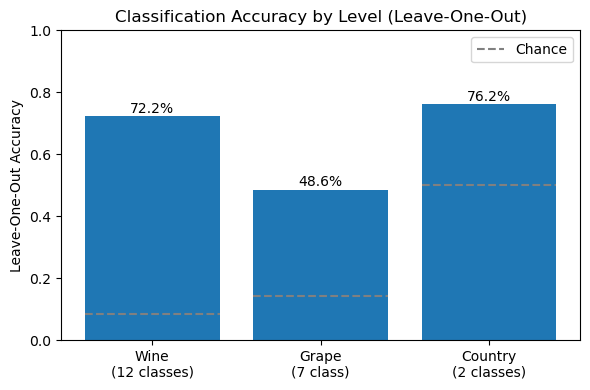

In [246]:
levels = ["Wine\n(12 classes)", "Grape\n(7 class)", "Country\n(2 classes)"]
acc = [cv_scores.mean(), cv_grape.mean(), cv_country.mean()]
chance = [1/12, 1/7, 1/2]

plt.figure(figsize = (6, 4))
plt.bar(levels, acc)
for i, (a, c) in enumerate(zip(acc, chance)):
    plt.hlines(c, i - 0.4, i + 0.4, linestyle = "--", color = "grey")
    plt.text(i, a + 0.01, f"{a:.1%}", ha = "center")

plt.plot([], [], linestyle = "--", color = "grey", label = "Chance")
plt.legend()
plt.ylabel("Leave-One-Out Accuracy")
plt.ylim(0, 1)
plt.title("Classification Accuracy by Level (Leave-One-Out)")
plt.tight_layout()
plt.show()

In [247]:
country_mask = country_labels.isin(["France", "USA"])
X_country = X_scaled_compact[country_mask]
y_country = country_labels[country_mask]


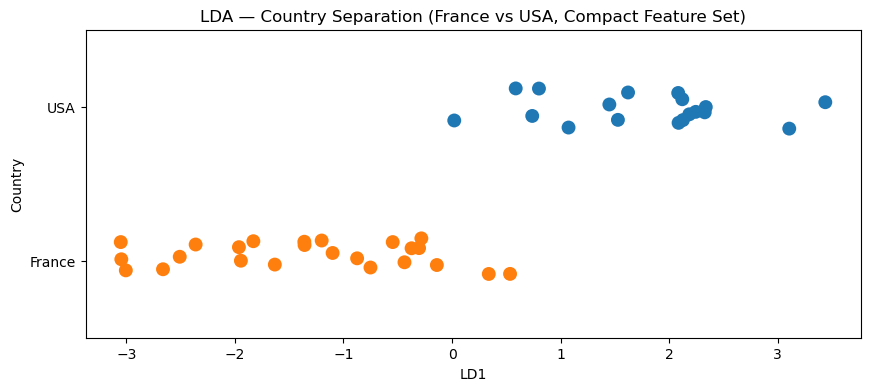

In [248]:
lda_country = LinearDiscriminantAnalysis(n_components = 1)
lda_country_scores = lda_country.fit_transform(X_country, y_country)

lda_country_df = pd.DataFrame(lda_country_scores, columns = ["LD1"])
lda_country_df["Country"] = y_country.values

plt.figure(figsize = (10, 4))
sns.stripplot(data = lda_country_df, x = "LD1", y = "Country", hue = "Country", s = 10, jitter = 0.15)
plt.title("LDA — Country Separation (France vs USA, Compact Feature Set)")
plt.show()

In [249]:
cv_country = cross_val_score(LinearDiscriminantAnalysis(), X_country, y_country, cv = LeaveOneOut())
print(f"Country-level (France vs USA) leave-one-out accuracy: {cv_country.mean():.3f}")

Country-level (France vs USA) leave-one-out accuracy: 0.762


Country-level LDA (restricted to France and USA, the only countries represented by more than one wine) achieves 76.2% leave-one-out accuracy, exceeding the 50% chance baseline for a two-class problem by a wide margin, and comparable to the 72.2% achieved at the individual wine level.

This result should, however, be interpreted cautiously. The grape variety and country are confounded within this 6 wine vs 6 wine comparison (ex. Syrah is represented only among France), so the separation observed cannot be fully attributed to geographic origin as distinct from grape variety or individual wine identity. Distinguishing a genuine country- or terroir-level effect from a grape-variety effect would require wines matched on grape variety across countries. A partial test of this is available in the pairwise grape-variety analysis, where same-grape, different-country pairs - Malbec (Texas vs Mendoza), Cabernet Sauvignon (California vs Ventoux), Pinot Noir (California vs Languedoc), and Merlot (Barossa vs Niagara) - each showed strong, statistically significant discrimination even with grape variety held constant. This provides more controlled, though still limited, evidence that geographic origin contributes a real discriminatory signal independent of grape variety alone. Rather than the country-level LDA result simply reflecting grape variety confounded with geography.

In [250]:
# 95% Wilson confidence intervals for reported accuracies
def wilson(k, n, z=1.96):
    p = k/n
    d = 1 + z**2/n
    c = (p + z**2/(2*n))/d
    h = (z/d)*(p*(1-p)/n + z**2/(4*n**2))**0.5
    return 100*(c-h), 100*(c+h)

for label, scores in [("Wine (unnested)", cv_scores),
                      ("Grape",           cv_grape),
                      ("Country",         cv_country)]:
    k, n = int(scores.sum()), len(scores)
    lo, hi = wilson(k, n)
    print(f"{label:<17} {k}/{n} = {100*k/n:.1f}%   CI [{lo:.1f}, {hi:.1f}]")

# Nested wine-level (53/72 from the nested LOOCV run above)
lo, hi = wilson(53, 72)
print(f"{'Wine (nested)':<17} 53/72 = 73.6%   CI [{lo:.1f}, {hi:.1f}]")

Wine (unnested)   52/72 = 72.2%   CI [61.0, 81.2]
Grape             35/72 = 48.6%   CI [37.4, 59.9]
Country           32/42 = 76.2%   CI [61.5, 86.5]
Wine (nested)     53/72 = 73.6%   CI [62.4, 82.4]


### Sensors that the wine-level classifier is relying on

In [251]:
#LDA coefficient magnitude per sensor - which sensors is the classifier using most heavily to distinguish wines

lda_coef_importance = pd.DataFrame(
    lda.coef_, columns = compact_matrix.columns
).abs().mean().sort_values(ascending = False)

print(lda_coef_importance)

Cu-WEEHEE-CAS       7.656672
Cu-FHFPHHF-CAS      7.477053
Cu-PHGGGWGQ-PCV     5.524232
Cu-WAHEDEFF-PCV     5.363286
Cu-WHCCHDHCD-PCV    5.051327
Ni-FHFPHHF-BPR      4.892977
Cu-WEHHHE-PCV       4.536324
Cu-WGHGGHHG-PCV     3.866550
Cu-WEEHEE-PCV       2.979570
Cu-WDDHDD-PCV       2.974618
Cu-FHFPHHF-PCV      2.871457
Cu-WDHHHD-PCV       1.456606
Cu-IHIGHHI-PCV      0.912537
Ni-WEEHEE-BPR       0.865614
dtype: float64


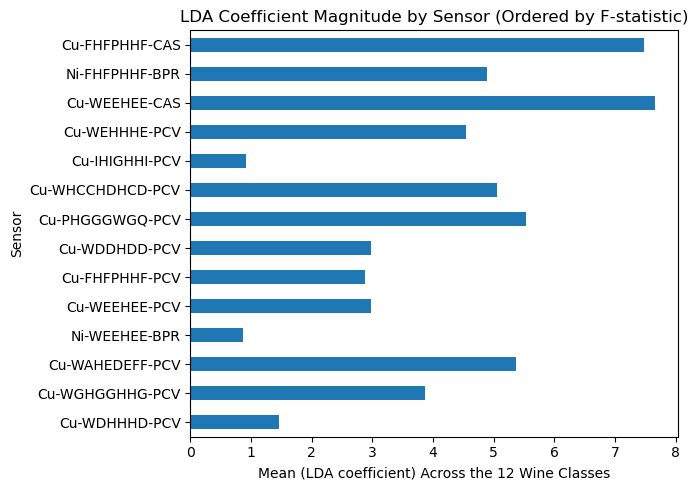

In [252]:
order = best_wavelength_per_sensor.sort_values("F_statistic")["Sensor"]
lda_coef_importance.reindex(order).plot.barh(figsize = (7, 5))
plt.xlabel("Mean (LDA coefficient) Across the 12 Wine Classes")
plt.title("LDA Coefficient Magnitude by Sensor (Ordered by F-statistic)")
plt.tight_layout()
plt.show()

## 9. Sensor reduction 

Maintaining a 14-sensor array is very expensive. A  follow-up question is whether classification accuracy holds up, or even improves, with fewer sensors. If this is the case, how many can be removed before performance meaningfully degrades.

Sensors are ranked from weakest to strongest by F-statistic (computed once on the full dataset), then removed from weakest to strongest, re-running wine-level LOOCV at each step.

In [253]:
f_stat_ranking = best_wavelength_per_sensor.sort_values("F_statistic")["Sensor"].tolist()

results = []
for n_drop in range(0, 8):
    drops = f_stat_ranking[:n_drop]
    reduced = compact_matrix.drop(columns = drops) if drops else compact_matrix
    X_reduced = StandardScaler().fit_transform(reduced)
    acc = cross_val_score(LinearDiscriminantAnalysis(), X_reduced, y, cv = LeaveOneOut()).mean()
    results.append({"Sensors_Dropped": n_drop, "Accuracy": acc})

results_df = pd.DataFrame(results)
print(results_df)

   Sensors_Dropped  Accuracy
0                0  0.722222
1                1  0.750000
2                2  0.777778
3                3  0.750000
4                4  0.736111
5                5  0.763889
6                6  0.750000
7                7  0.763889


   Sensors_Dropped  Accuracy
0                0  0.722222
1                1  0.750000
2                2  0.777778
3                3  0.750000
4                4  0.736111
5                5  0.763889
6                6  0.750000
7                7  0.763889
Sensors dropped at peak: ['Cu-WDHHHD-PCV', 'Cu-WGHGGHHG-PCV']


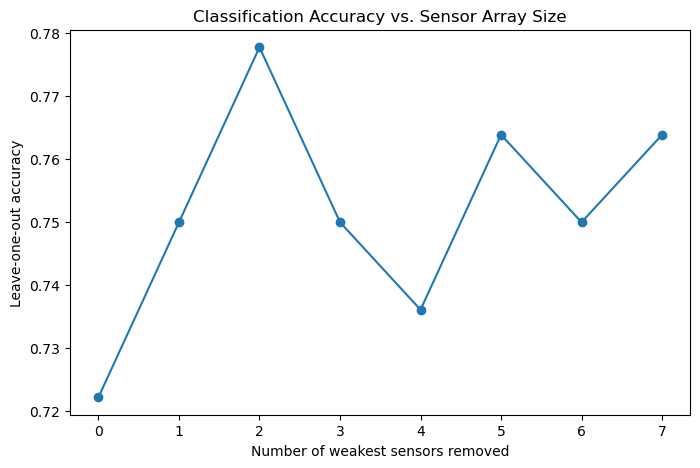

In [254]:
print(results_df)
print(f"Sensors dropped at peak: {f_stat_ranking[:2]}")

plt.figure(figsize = (8, 5))
plt.plot(results_df["Sensors_Dropped"], results_df["Accuracy"], marker = "o")
plt.xlabel("Number of weakest sensors removed")
plt.ylabel("Leave-one-out accuracy")
plt.title("Classification Accuracy vs. Sensor Array Size")
plt.show()

First result (fail, unnested): Classification accuracy peaks after removing the two weakest sensors by F-statistic - Cu-WDHHHD-PCV and Cu-WGHGGHHG-PCV - improving leave-one-out accuracy from 72.2% to 77.8%.

This result does not hold up under nested cross-validation — see Section 10 below. The sensor ranking used here was computed once on the full 72-sample dataset before cross-validation, meaning each held-out test sample had already influenced which sensors were judged the weakest. When sensor ranking is instead recomputed independently within each LOOCV fold, this specific two-sensor removal is no longer the best- performing option, and the accuracy curve as a whole becomes essentially flat with no confident peak. The first result is kept to see the the contrast between the nested and unnested version. Deomstrating why feature/sensor selection has to happen inside cross-validation rather than before it. 

## 10. Nested cross-validation

Sections 6 and 8 both rely on leave-one-out cross-validation as evidence that results generalize. But the feature selection feeding into those results (which wavelength represents each sensor, and which sensors are weakest) was computed once on the full 72-sample dataset, before cross-validation ran. That means the held-out sample in every LOOCV fold had already had a hand in choosing the features it was later tested on. This is a form of data leakage that can inflate accuracy.

For each of the 72 LOOCV folds, wavelength selection (and sensor ranking for the sensor-reduction check) is recomputed using only that fold's 71 training samples. The held-out sample plays no part in choosing the features it's then tested on. This is a slower, more computationally expensive procedure, but it's the version of the result that can  be trusted as an unbiased estimate.

In [255]:
#Vectorized F-statistic scan restricted to a training subset which is used inside each nested-CV fold
#Computes the one-way ANOVA F-statistic for every sensor,wavelength combination in a single vectorized pass

def best_wavelength_per_sensor_from(df_train):
    
    df_train = df_train[df_train["Sensor"] != "Wine control"]

    wide = df_train.pivot_table(
        index=["Wine", "Replicate"],
        columns=["Sensor", "Wavelength"],
        values="Absorbance",
    )

    wine_labels = wide.index.get_level_values("Wine")
    grouped = wide.groupby(wine_labels)

    n_per_group = grouped.size()
    k = len(n_per_group)
    N = len(wide)

    group_means = grouped.mean()
    grand_mean = wide.mean()

    ssb = ((group_means - grand_mean) ** 2).mul(n_per_group, axis=0).sum(axis=0)
    group_var = grouped.var(ddof=1)
    ssw = group_var.mul((n_per_group - 1), axis=0).sum(axis=0)

    df_between = k - 1
    df_within = N - k

    f_stat = (ssb / df_between) / (ssw / df_within)

    f_stat_df = f_stat.reset_index()
    f_stat_df.columns = ["Sensor", "Wavelength", "F_statistic"]

    best = f_stat_df.loc[f_stat_df.groupby("Sensor")["F_statistic"].idxmax()]
    return best.sort_values("F_statistic", ascending=False).reset_index(drop=True)


In [256]:
#Builds the wine, replicate x sensor matrix of corrected absorbance at each sensor's selected best wavelength

def build_compact_vector(corrected_all_subset, best_wavelength_df):
    
    features = []
    for _, row in best_wavelength_df.iterrows():
        sensor, wl = row["Sensor"], row["Wavelength"]
        subset = corrected_all_subset[
            (corrected_all_subset["Sensor"] == sensor)
            & (corrected_all_subset["Wavelength"] == wl)
        ]
        subset = subset[["Wine", "Replicate", "Corrected_Absorbance"]].rename(
            columns={"Corrected_Absorbance": sensor}
        )
        features.append(subset.set_index(["Wine", "Replicate"]))
    return pd.concat(features, axis=1)


### Nested LOOCV — wine-level accuracy

In [257]:
#Nested LOOCV for the 12-class wine-level LDA accuracy
#Wavelength selection is recomputed within each fold using training data only

def nested_loocv_wine_level(master_df_384, corrected_all, verbose_every=10):
   
    sample_index = corrected_all.drop_duplicates(["Wine", "Replicate"])[
        ["Wine", "Replicate"]
    ].reset_index(drop=True)

    preds, truths = [], []
    n = len(sample_index)

    for i in range(n):
        test_wine, test_rep = sample_index.loc[i, ["Wine", "Replicate"]]

        train_master = master_df_384[
            ~((master_df_384["Wine"] == test_wine) & (master_df_384["Replicate"] == test_rep))
        ]
        train_corrected = corrected_all[
            ~((corrected_all["Wine"] == test_wine) & (corrected_all["Replicate"] == test_rep))
        ]
        test_corrected = corrected_all[
            (corrected_all["Wine"] == test_wine) & (corrected_all["Replicate"] == test_rep)
        ]

        best_wl_train = best_wavelength_per_sensor_from(train_master)

        X_train_df = build_compact_vector(train_corrected, best_wl_train)
        X_test_df = build_compact_vector(test_corrected, best_wl_train)
        X_test_df = X_test_df[X_train_df.columns]

        y_train = X_train_df.index.get_level_values("Wine")
        y_test = test_wine

        scaler = StandardScaler().fit(X_train_df)
        X_train = scaler.transform(X_train_df)
        X_test = scaler.transform(X_test_df)

        clf = LinearDiscriminantAnalysis()
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)[0]

        preds.append(pred)
        truths.append(y_test)

        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"  fold {i + 1}/{n} done")

    preds = np.array(preds)
    truths = np.array(truths)
    accuracy = (preds == truths).mean()
    return accuracy, preds, truths


nested_wine_acc, nested_preds, nested_truths = nested_loocv_wine_level(master_df_384, corrected_all)
print(f"Nested wine-level LOOCV accuracy: {nested_wine_acc:.3f}")


  fold 10/72 done
  fold 20/72 done
  fold 30/72 done
  fold 40/72 done
  fold 50/72 done
  fold 60/72 done
  fold 70/72 done
Nested wine-level LOOCV accuracy: 0.736


Nested LOOCV gives 73.6% wine-level accuracy, closely matching the unnested estimate of 72.2%, just a 1-sample difference out of 72 and in the opposite direction from what leakage-driven inflation would predict. This indicates the wine-level headline result was not meaningfully inflated by wavelength selection preceding cross-validation.

### Nested LOOCV — sensor-reduction curve

In [258]:
#Nested LOOCV for the sensor-reduction curve
#Ranking is computed within each fold ulsed training data only, before dropping the n_drop weakest sensors for that fold

def nested_loocv_sensor_reduction(master_df_384, corrected_all, max_drop=7, verbose=True):

    sample_index = corrected_all.drop_duplicates(["Wine", "Replicate"])[
        ["Wine", "Replicate"]
    ].reset_index(drop=True)

    results = []
    n = len(sample_index)

    for n_drop in range(0, max_drop + 1):
        preds, truths = [], []

        for i in range(n):
            test_wine, test_rep = sample_index.loc[i, ["Wine", "Replicate"]]

            train_master = master_df_384[
                ~((master_df_384["Wine"] == test_wine) & (master_df_384["Replicate"] == test_rep))
            ]
            train_corrected = corrected_all[
                ~((corrected_all["Wine"] == test_wine) & (corrected_all["Replicate"] == test_rep))
            ]
            test_corrected = corrected_all[
                (corrected_all["Wine"] == test_wine) & (corrected_all["Replicate"] == test_rep)
            ]

            best_wl_train = best_wavelength_per_sensor_from(train_master)

            ranked = best_wl_train.sort_values("F_statistic")
            keep_sensors = ranked["Sensor"].tolist()[n_drop:] if n_drop > 0 else ranked["Sensor"].tolist()
            best_wl_train_reduced = best_wl_train[best_wl_train["Sensor"].isin(keep_sensors)]

            X_train_df = build_compact_vector(train_corrected, best_wl_train_reduced)
            X_test_df = build_compact_vector(test_corrected, best_wl_train_reduced)
            X_test_df = X_test_df[X_train_df.columns]

            y_train = X_train_df.index.get_level_values("Wine")
            y_test = test_wine

            scaler = StandardScaler().fit(X_train_df)
            X_train = scaler.transform(X_train_df)
            X_test = scaler.transform(X_test_df)

            clf = LinearDiscriminantAnalysis()
            clf.fit(X_train, y_train)
            pred = clf.predict(X_test)[0]

            preds.append(pred)
            truths.append(y_test)

        preds = np.array(preds)
        truths = np.array(truths)
        acc = (preds == truths).mean()
        results.append({"Sensors_Dropped": n_drop, "Accuracy": acc})
        if verbose:
            print(f"n_drop={n_drop}: nested LOOCV accuracy = {acc:.3f}")

    return pd.DataFrame(results)


nested_reduction_results = nested_loocv_sensor_reduction(master_df_384, corrected_all)
print(nested_reduction_results)


n_drop=0: nested LOOCV accuracy = 0.736
n_drop=1: nested LOOCV accuracy = 0.736
n_drop=2: nested LOOCV accuracy = 0.722
n_drop=3: nested LOOCV accuracy = 0.736
n_drop=4: nested LOOCV accuracy = 0.736
n_drop=5: nested LOOCV accuracy = 0.778
n_drop=6: nested LOOCV accuracy = 0.750
n_drop=7: nested LOOCV accuracy = 0.750
   Sensors_Dropped  Accuracy
0                0  0.736111
1                1  0.736111
2                2  0.722222
3                3  0.736111
4                4  0.736111
5                5  0.777778
6                6  0.750000
7                7  0.750000


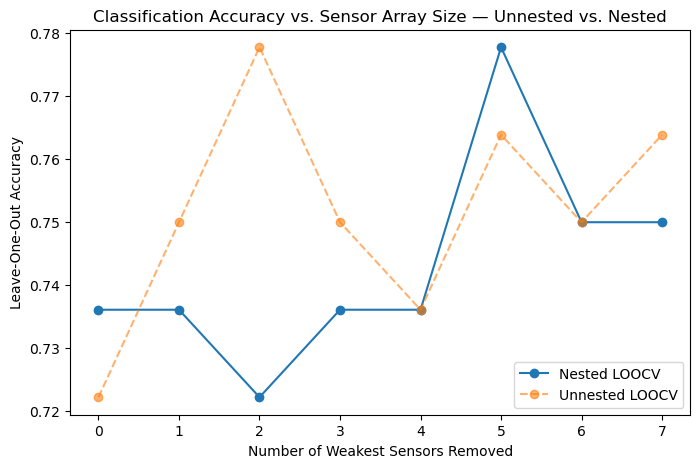

In [259]:
plt.figure(figsize=(8, 5))
plt.plot(nested_reduction_results["Sensors_Dropped"], nested_reduction_results["Accuracy"], marker="o", label="Nested LOOCV")
plt.plot(results_df["Sensors_Dropped"], results_df["Accuracy"], marker="o", linestyle="--", alpha=0.6, label="Unnested LOOCV")
plt.xlabel("Number of Weakest Sensors Removed")
plt.ylabel("Leave-One-Out Accuracy")
plt.title("Classification Accuracy vs. Sensor Array Size — Unnested vs. Nested")
plt.legend()
plt.show()


Nested result: Accuracy ranges narrowly from 72.2% to 77.8% across n_drop = 0 to 7, with no stable, confidently-identifiable peak. Critically, n_drop = 2, the unnested analysis's headline result, is the worst point on the nested curve (72.2%). Below the zero-sensors-dropped baseline (73.6%). The naive analysis's specific two-sensor recommendation does not survive this validation.

This divergence, in contrast to the wine-level check above holding up well, makes sense. Selecting a wavelength per sensor is relatively stable (14 independent choices, each drawing on 226 wavelengths' worth of data), but ranking 14 sensors from weakest to strongest and cutting a hard threshold through that ranking is far more sensitive to exactly which sample is held out. Especially near the threshold where sensors' F-statistics are likely close together. There's also a conceptual issue independent of the accuracy numbers. Because sensor ranking is recomputed per fold, the two weakest sensors isn't a fixed, reusable pair of physical sensors in the nested version. It can vary fold to fold, so this procedure can report an accuracy at a given number of dropped sensors, but can't report a fixed list of which sensors to  remove from the array the way the unnested version appeared to.

With the current sample size, there isn't a confident, validated basis for dropping any specific sensor from the 14-sensor array. This is a meaningful answer, and a more defensible one than the unnested result. 

## 11. Grape-variety-pair sub-analysis

The country-level LDA above is confounded with grape variety, so a cleaner test of a geography that is independent of grape effect is to compare wines that share a grape variety but differ in region, one pair at a time. One pair (Syrah, W4 vs W8) shares both grape and region, and is included as a further check on whether the array can resolve differences finer than terroir.

Each pair's "best sensor" is selected by testing all 14 sensors and reporting the strongest one, without a multiple-comparisons correction across those 14 tests per pair (or across the 5 pairs overall). The F-statistics reported below should be read as exploratory/hypothesis-generating evidence of discrimination, not a formally corrected significance tests.

In [260]:
grape_pairs = {
    "Malbec (Texas vs Mendoza)": ["W1", "W7"],
    "Cabernet Sauvignon (California vs Ventoux)": ["W2", "W10"],
    "Pinot Noir (California vs Languedoc)": ["W5", "W12"],
    "Merlot (Barossa vs Niagara)": ["W6", "W11"],
    "Syrah (Rhone Valley, same region)": ["W4", "W8"],
}

pair_results = []

for label, wines in grape_pairs.items():
    pair_matrix = compact_matrix[compact_matrix.index.get_level_values("Wine").isin(wines)]
    y_pair = pair_matrix.index.get_level_values("Wine")

    #Per-sensor F-statistic for this pair specifically (equivalent to a t-test with 2 groups)
    sensor_scores = []
    for sensor in pair_matrix.columns:
        groups = [g.values for _, g in pair_matrix[sensor].groupby(y_pair)]
        f_stat, p_val = stats.f_oneway(*groups)
        sensor_scores.append({"Sensor": sensor, "F_statistic": f_stat, "p_value": p_val})

    best_sensor = pd.DataFrame(sensor_scores).sort_values("F_statistic", ascending = False).iloc[0]

    pair_results.append({
        "Pair": label,
        "Best_Sensor": best_sensor["Sensor"],
        "F_statistic": best_sensor["F_statistic"],
        "p_value": best_sensor["p_value"]
    })

pair_results_df = pd.DataFrame(pair_results)
print(pair_results_df)

                                         Pair     Best_Sensor  F_statistic  \
0                   Malbec (Texas vs Mendoza)  Ni-FHFPHHF-BPR    27.334805   
1  Cabernet Sauvignon (California vs Ventoux)   Cu-WEEHEE-CAS   648.273760   
2        Pinot Noir (California vs Languedoc)   Cu-WEHHHE-PCV    71.512539   
3                 Merlot (Barossa vs Niagara)   Ni-WEEHEE-BPR   160.333681   
4           Syrah (Rhone Valley, same region)   Cu-WEEHEE-PCV    42.381362   

        p_value  
0  3.852532e-04  
1  2.003711e-10  
2  7.218652e-06  
3  1.759959e-07  
4  6.807749e-05  


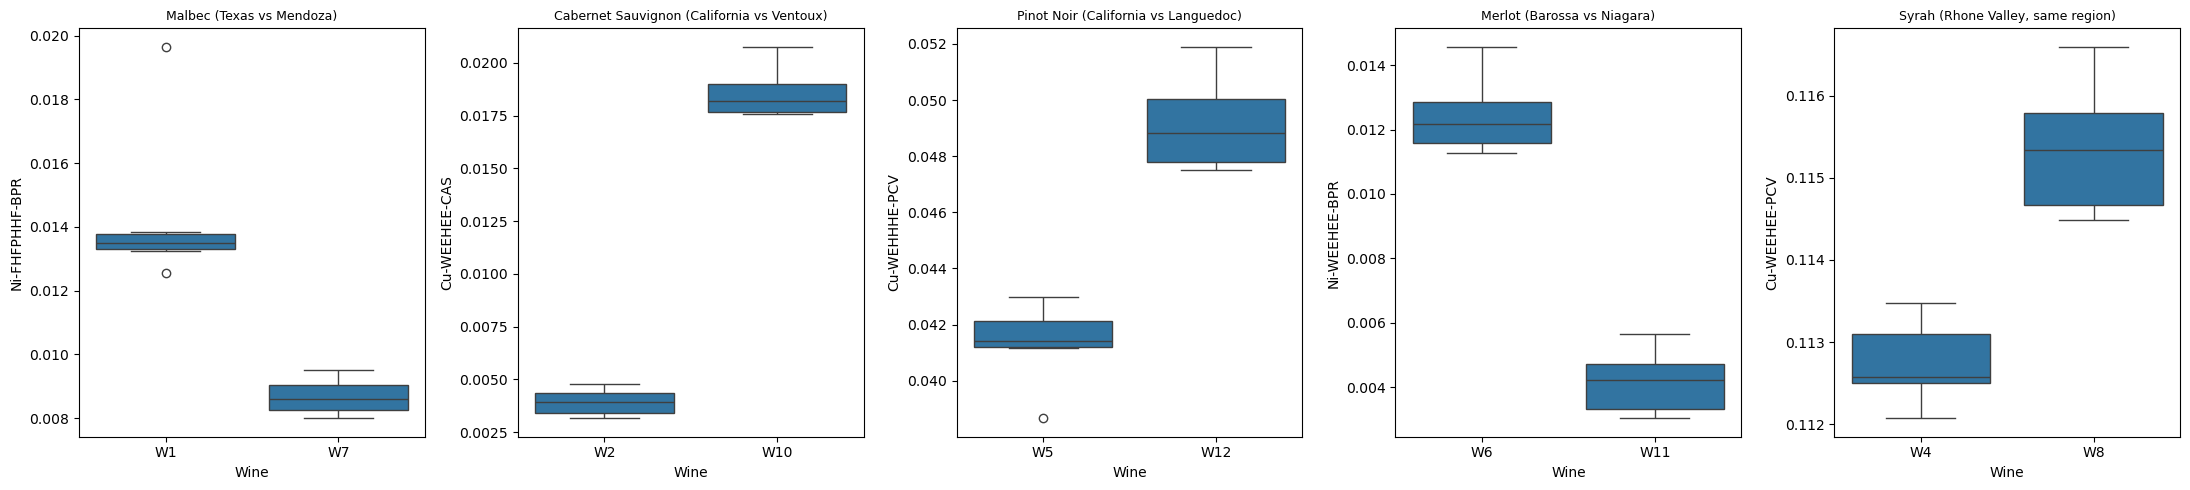

In [261]:
#Visualize each pair on its single best-discriminating sensor

fig, axes = plt.subplots(1, 5, figsize = (22, 5))

for ax, (label, wines) in zip(axes, grape_pairs.items()):
    pair_matrix = compact_matrix[compact_matrix.index.get_level_values("Wine").isin(wines)].reset_index()
    best_sensor_for_pair = pair_results_df[pair_results_df["Pair"] == label]["Best_Sensor"].values[0]

    sns.boxplot(data = pair_matrix, x = "Wine", y = best_sensor_for_pair, ax = ax)
    ax.set_title(label, fontsize = 9)

plt.tight_layout()
plt.show()

All five grape-variety pairs show statistically significant discrimination, several with very large effect sizes: Cabernet Sauvignon (California vs Ventoux, F = 648.3), Merlot (Barossa vs Niagara, F = 160.3), Pinot Noir (California vs Languedoc, F = 71.5), Malbec (Texas vs Mendoza, F = 27.3), and Syrah (F = 42.4). The Syrah pair is particularly notable: W4 and W8 share both grape variety and region (Rhone Valley), yet remain clearly distinguishable, indicating the sensing array is capable of resolving differences finer than terroir alone. This could reflect producer or vintage-level variation and answers whether the array can discriminate wines sharing a grape variety across different regions. While extending the finding further by showing discrimination is possible even between wines sharing both grape and region.

## Summary

Full-feature PCA (3,164 features, 72 samples) did not reveal reliable wine structure, with its dominant component driven by weak, non-discriminating sensors rather than wine-related variance. This is an expected consequence of feature dimensionality far exceeding sample size. Restricting each sensor to its single most informative wavelength produced a compact-feature vector, on which all subsequent methods were tested.

This restriction also corrected an earlier conclusion that the sensors previously identified as non-discriminating (e.g. Ni-FHFPHHF-BPR) were found to be strong discriminators at their own optimal wavelength, indicating that band choice explained the earlier result. At their individually optimal wavelengths, all 14 sensors discriminate wine significantly, and no sensor is currently supported for removal from the array. A conclusion also strengthened by the nested cross-validation result in Section 10, which found no sensor combination whose removal reliably and confidently improves accuracy.

Of the three multivariate methods applied to the compact vector, LDA produced the strongest result with a 72.2% leave-one-out cross-validated accuracy across 12 wine classes, against an 8.3% chance baseline. Seven of twelve wines were classified correctly in nearly all trials. The remaining error was concentrated in a specific, bidirectional confusion between two chemically and geographically unrelated wines (W2, W4), alongside a more diffuse pattern in which one wine (W6) was confused with several others rather than one clear counterpart. PCA and UMAP, as unsupervised methods, produced comparatively partial separation, consistent with wine-related variance not being the dominant source of variation in the dataset overall.

The sensor-reduction analysis illustrates the importance of validating feature-selection procedures correctly. An unnested analysis suggested removing two specific weak sensors improved accuracy from 72.2% to 77.8%, but this result did not survive nested cross-validation, under which the same two-sensor removal performed worst on the curve. Concluding that no specific sensor reduction is currently supported by this dataset.

A targeted sub-analysis of wine pairs sharing grape variety found significant discrimination in every pair tested, including one pair (Syrah, W4 vs W8) sharing both grape variety and region. Which indicates the sensing array is capable of resolving compositional differences beyond grape and terroir alone. Notably, this same wine (W4) was also the wine most frequently confused with an unrelated wine (W2) in the full 12-class LDA analysis, suggesting that strong pairwise discrimination between two specific wines does not necessarily extend to reliable discrimination against every other wine in the full dataset.

Together, these results support the feasibility of wine discrimination using this sensing array, with the strongest evidence coming from supervised classification (LDA) rather than unsupervised dimensionality reduction (PCA, UMAP), and with that evidence holding up under nested cross-validation. Further work should focus on characterizing why specific wine pairs (e.g. W2/W4) remain difficult to separate, given that neither shared grape variety nor region explains the confusion observed, and on collecting additional replicates before revisiting whether any sensor can be confidently dropped from the array.